In [3]:
import os
import pandas as pd
import numpy as np

def load_scenario_data(scenario_id, base_path=r"D:\LeakDB_full_data\Hanoi"):
    try:
        scenario_path = os.path.join(base_path, f"Scenario-{scenario_id}")
        if not os.path.exists(scenario_path):
            print(f"Scenario {scenario_id} not found.")
            return None
        
        leaks, timestamps = None, None
        demand_path = flow_path = pressure_path = None
        for sub in os.listdir(scenario_path):
            if sub in [f"Scenario-{scenario_id}", f"Scenario-{scenario_id}_info.csv", f"Hanoi_CMH_Scenario-{scenario_id}.inp"]:
                continue
            sub_path = os.path.join(scenario_path, sub)
            if sub == "Demands":
                demand_path = sub_path
            elif sub == "Flows":
                flow_path = sub_path
            elif sub == "Pressures":
                pressure_path = sub_path
            elif sub == "Labels.csv":
                leaks = pd.read_csv(sub_path).drop(columns=["Index"], errors="ignore")
            elif sub == "Timestamps.csv":
                timestamps = pd.read_csv(sub_path).drop(columns=["Index"], errors="ignore")

        if not all([demand_path, flow_path, pressure_path, leaks is not None, timestamps is not None]):
            print(f"Scenario {scenario_id} is incomplete.")
            return None

        df = pd.concat([leaks, timestamps], axis=1, ignore_index=True)
        df.columns = ["Leaks", "Timestamps"]

        def combined_feature_df(path, feature):
            dfs = []
            for file in sorted(os.listdir(path)):
                file_path = os.path.join(path, file)
                if not file.endswith(".csv"):
                    continue
                sub_df = pd.read_csv(file_path).drop(columns="Index", errors="ignore")
                sub_df.columns = [f"{feature}_{file.split('.')[0]}"]
                dfs.append(sub_df)
            return pd.concat(dfs, axis=1, ignore_index=True)

        demand_df = combined_feature_df(demand_path, "demand")
        pressure_df = combined_feature_df(pressure_path, "pressure")
        flow_df = combined_feature_df(flow_path, "flow")

        demand_df.columns = [f"demand_node_{i}" for i in range(1, demand_df.shape[1] + 1)]
        pressure_df.columns = [f"pressure_node_{i}" for i in range(1, pressure_df.shape[1] + 1)]
        flow_df.columns = [f"flow_link_{i}" for i in range(1, flow_df.shape[1] + 1)]

        final_df = pd.concat([demand_df, pressure_df, flow_df, df], axis=1)
        final_df["Leaks"] = final_df["Leaks"].astype(int)
        return final_df

    except Exception as e:
        print(f"Error loading scenario {scenario_id}: {e}")
        return None


In [4]:
def aggregate_nonleak_rows(df, leak_col="Leaks"):
    data_cols = [c for c in df.columns if c != "Timestamps" and c != leak_col]
    out_rows = []
    i = 0
    n = len(df)
    while i < n:
        if df.iloc[i][leak_col] == 1:
            out_rows.append(df.iloc[i][data_cols + [leak_col]].to_dict())
            i += 1
            continue
        j = i
        while j < n and df.iloc[j][leak_col] == 0:
            j += 1
        run_len = j - i
        k = i
        while k + 3 <= j:
            window = df.iloc[k:k+3]
            avg_vals = window[data_cols].mean(axis=0).to_dict()
            avg_vals[leak_col] = 0
            out_rows.append(avg_vals)
            k += 3
        while k < j:
            out_rows.append(df.iloc[k][data_cols + [leak_col]].to_dict())
            k += 1
        i = j
    out_df = pd.DataFrame(out_rows)
    return out_df

In [5]:
def compute_global_mean_std(df_list):
    sum_ = None
    sumsq_ = None
    n_total = 0
    for df in df_list:
        arr = df.drop(columns=["Leaks"]).values.astype(np.float64)
        if sum_ is None:
            sum_ = arr.sum(axis=0)
            sumsq_ = (arr**2).sum(axis=0)
        else:
            sum_ += arr.sum(axis=0)
            sumsq_ += (arr**2).sum(axis=0)
        n_total += arr.shape[0]
    mean = sum_ / n_total
    var = (sumsq_ / n_total) - (mean**2)
    std = np.sqrt(np.maximum(var, 1e-6))
    return mean.astype(np.float32), std.astype(np.float32)

def normalize_df(df, mean, std):
    cols = [c for c in df.columns if c != "Leaks"]
    df2 = df.copy()
    df2[cols] = (df2[cols] - mean) / std
    return df2

In [6]:
import numpy as np

def create_windowed_data(df_list, window_size=5, step=1):
    X, y = [], []

    for df in df_list:
        arr = df.drop(columns=["Leaks"]).values.astype(np.float32)
        labs = df["Leaks"].values.astype(np.int64)
        T, F = arr.shape

        for start in range(0, T - window_size + 1, step):
            window = arr[start:start + window_size].reshape(-1)
            target = labs[start + window_size - 1]
            X.append(window)
            y.append(target)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)

    return X, y


In [10]:
df_trial = load_scenario_data(434, base_path=r"D:\LeakDB_full_data\Hanoi")
df_trial["Leaks"].value_counts()

Leaks
0    13295
1     4225
Name: count, dtype: int64

In [11]:
df_after_agg = aggregate_nonleak_rows(df_trial, "Leaks")

print("="*20)
print("Data frame after aggregation, leak count:")
print(df_after_agg["Leaks"].value_counts())
print("="*20)

Data frame after aggregation, leak count:
Leaks
0    4433
1    4225
Name: count, dtype: int64


In [12]:
df_list = [df_after_agg]

mean, std = compute_global_mean_std(df_list)
(mean, std)

(array([-5538.7817   ,   136.10257  ,   149.51448  ,   166.72197  ,
          258.61816  ,   157.56299  ,    72.06001  ,    82.14373  ,
          250.73334  ,   374.23175  ,    15.949411 ,   234.89896  ,
          347.0679   ,   250.4061   ,   145.75981  ,   292.17242  ,
          217.442    ,    45.777687 ,   260.33707  ,   109.28912  ,
           80.06417  ,   101.39057  ,   230.87984  ,    93.781845 ,
           28.802494 ,   204.02454  ,    36.240192 ,   201.27151  ,
          268.186    ,   396.1142   ,   142.61067  ,   152.59958  ,
            0.       ,    64.409386 ,    64.20337  ,    64.15367  ,
           63.75778  ,    63.14609  ,    62.951366 ,    62.821285 ,
           63.180138 ,    64.358795 ,    65.33365  ,    69.75421  ,
           64.49886  ,    62.179382 ,    61.84795  ,    64.11453  ,
           63.826977 ,    63.417458 ,    62.785873 ,    62.60358  ,
           62.97371  ,    62.559414 ,    66.09532  ,    62.521008 ,
           62.595646 ,    63.004055 ,    65.8107

In [14]:
df_after_agg = normalize_df(df_after_agg, mean, std)
df_after_agg.head(5)

,demand_node_1,demand_node_2,demand_node_3,demand_node_4,demand_node_5,demand_node_6,demand_node_7,demand_node_8,demand_node_9,demand_node_10,...,flow_link_26,flow_link_27,flow_link_28,flow_link_29,flow_link_30,flow_link_31,flow_link_32,flow_link_33,flow_link_34,Leaks
0,3.452142,-3.370944,-3.237825,-3.484596,-3.296934,-3.702139,-3.250986,-3.729208,-3.245084,-3.000937,...,3.207728,-3.225388,-3.067815,-3.497691,-3.526354,-3.488090,-3.327529,-3.355975,-3.403916,0
1,3.452418,-3.381744,-3.246644,-3.493340,-3.303488,-3.709278,-3.267352,-3.745855,-3.249451,-3.004536,...,3.226297,-3.238701,-3.072845,-3.498399,-3.527139,-3.488993,-3.328644,-3.357215,-3.405388,0
2,3.452406,-3.383184,-3.246093,-3.492311,-3.303873,-3.709927,-3.262676,-3.748233,-3.249054,-3.004306,...,3.220726,-3.234605,-3.072273,-3.498377,-3.527135,-3.488978,-3.328636,-3.357225,-3.405414,0
3,3.452081,-3.368783,-3.236171,-3.483053,-3.296548,-3.698245,-3.241634,-3.724452,-3.242702,-3.000555,...,3.204014,-3.221291,-3.066443,-3.497575,-3.526225,-3.487936,-3.327316,-3.355741,-3.403638,0
4,3.451515,-3.348622,-3.219635,-3.462993,-3.286332,-3.677476,-3.204226,-3.686402,-3.233374,-2.991368,...,3.174303,-3.197737,-3.058213,-3.496074,-3.524534,-3.486041,-3.325095,-3.353223,-3.400815,0


In [16]:
X, Y = create_windowed_data([df_after_agg], 5, 1)

In [19]:
len(X)

8654

In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=3)
X_bal, Y_bal = smote.fit_resample(X, Y)

print("Before SMOTE:", np.bincount(Y))
print("After SMOTE:", np.bincount(Y_bal))

Before SMOTE: [4429 4225]
After SMOTE: [4429 4429]


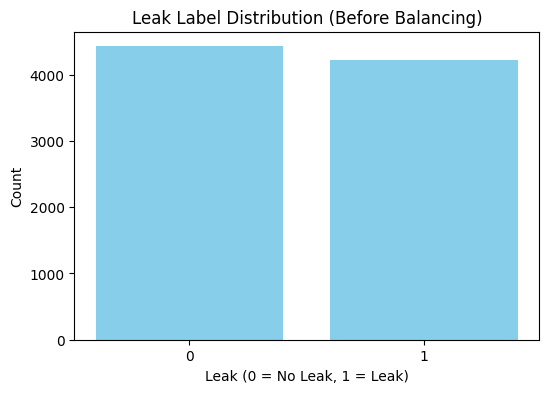

In [21]:
import matplotlib.pyplot as plt
import numpy as np

unique, counts = np.unique(Y, return_counts=True)

plt.figure(figsize=(6,4))
plt.bar(unique, counts, color='skyblue')
plt.xticks(unique)
plt.title("Leak Label Distribution (Before Balancing)")
plt.xlabel("Leak (0 = No Leak, 1 = Leak)")
plt.ylabel("Count")
plt.show()

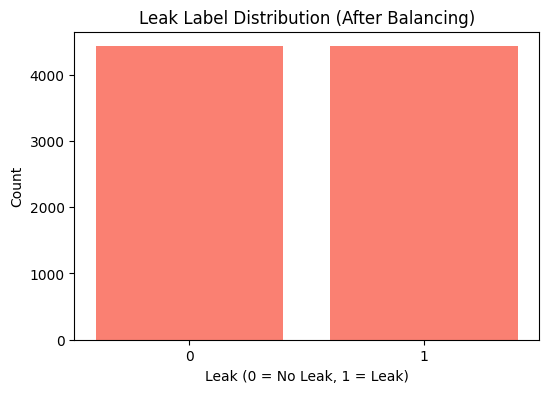

In [22]:
unique, counts = np.unique(Y_bal, return_counts=True)

plt.figure(figsize=(6,4))
plt.bar(unique, counts, color='salmon')
plt.xticks(unique)
plt.title("Leak Label Distribution (After Balancing)")
plt.xlabel("Leak (0 = No Leak, 1 = Leak)")
plt.ylabel("Count")
plt.show()

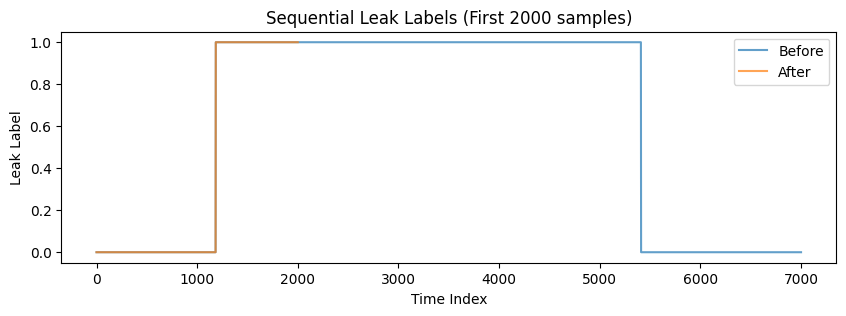

In [25]:
plt.figure(figsize=(10,3))
plt.plot(Y[:7000], label="Before", alpha=0.7)
plt.plot(Y_bal[:2000], label="After", alpha=0.7)
plt.legend()
plt.title("Sequential Leak Labels (First 2000 samples)")
plt.xlabel("Time Index")
plt.ylabel("Leak Label")
plt.show()

